In [10]:
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt

# Download dataset
path = kagglehub.dataset_download("unclesamulus/blood-cells-image-dataset")
root = Path(path)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'blood-cells-image-dataset' dataset.
Path to dataset files: /kaggle/input/blood-cells-image-dataset


In [13]:
from collections import Counter

# Find every .jpg and note which folder it's in
# The root.rglob provides a path link to one image file (https://docs.python.org/3/library/pathlib.html#basic-use)
all_images = list(root.rglob("*.jpg"))

# Count the number of blood cell types extracted
counts = Counter() #https://realpython.com/python-counter/#constructing-counters
for img in all_images:
  class_name = img.parent.name
  counts[class_name] += 1

# From the kaggle dataset, add the number of images for each blood cell type
expected = {
    "neutrophil":   3329,
    "eosinophil":   3117,
    "ig":           2895,
    "platelet":     2348,
    "erythroblast": 1551,
    "monocyte":     1420,
    "basophil":     1218,
    "lymphocyte":   1214,
}

# Print results
for class_name, count in sorted(counts.items()):
    expected_count = expected.get(class_name)
    print(class_name, "- found:", count, "expected:", expected_count)

basophil - found: 1218 expected: 2348
eosinophil - found: 3117 expected: 2348
erythroblast - found: 1551 expected: 2348
ig - found: 2895 expected: 2348
lymphocyte - found: 1214 expected: 2348
monocyte - found: 1420 expected: 2348
neutrophil - found: 3329 expected: 2348
platelet - found: 2348 expected: 2348


bloodcells_dataset


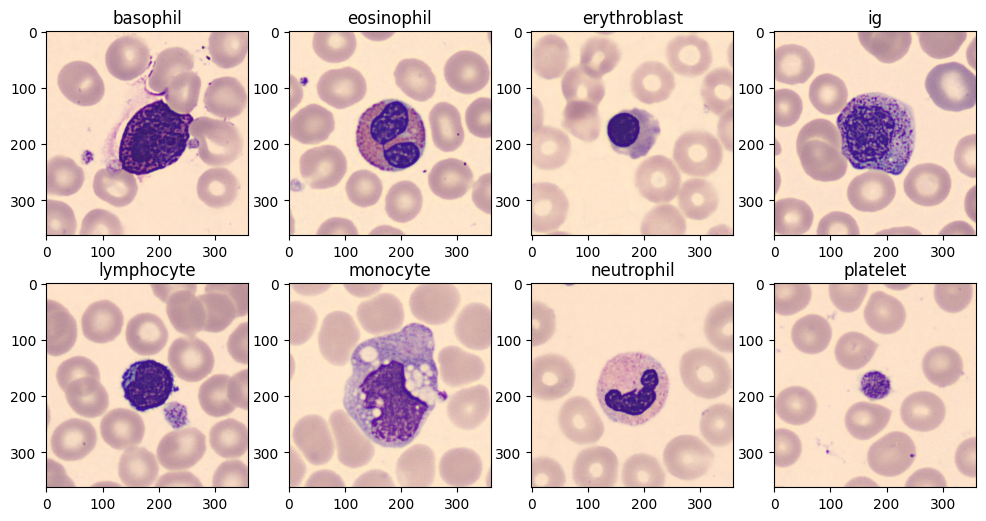

In [25]:
# Find the folder name of the dataset
for folder in sorted(root.iterdir()):
    print(folder.name)

# Get the class name from dict
class_names = sorted(counts.keys())

# Create a grid to get images (2 rows, 4 columns) (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Create a for loop to fill in the grid with pictures
for i in range(8):
    row = i // 4
    col = i % 4

    # Find the root path of each cell type and read the first image
    folder = root / "bloodcells_dataset" / class_names[i]
    image_file = list(folder.glob("*.jpg"))[0]
    img = plt.imread(str(image_file))

    axes[row, col].imshow(img)
    axes[row, col].set_title(class_names[i])

plt.show()

Preprocessing
- be resized to 224×224 pixels for VGG16 (what about the other models?)
- be normalized using ImageNet channel means and standard deviations (μ = [0.485, 0.456, 0.406], σ = [0.229, 0.224, 0.225]) (why these values?)
- split into training and testing (70/30)

In [26]:
from sklearn.model_selection import train_test_split

# Get all image paths and their class labels as two lists
image_paths = []
labels = []

for img in all_images:
    image_paths.append(str(img))
    labels.append(img.parent.name)

# Test split 15%
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.15, random_state=42, stratify=labels
)

# Train split 70% train and val 15%
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels, test_size=15/85, random_state=42, stratify=trainval_labels
)

# Check the sizes
print("Train:", len(train_paths))
print("Val:  ", len(val_paths))
print("Test: ", len(test_paths))

Train: 11964
Val:   2564
Test:  2564


- Data augmentation random horizontal flipping and small rotations (±15°) (why only 15?)